
>>> Тест: Log-Barrier (n=100)
Метод                | Итер   | Время (с) 
---------------------------------------------
GD Wolfe             | 1999   | 1.7683
Newton               | 99     | 0.4398
BFGS Manual          | 1999   | 4.6949
SciPy BFGS           | 0      | 0.0299
SciPy L-BFGS-B       | 0      | 0.0034


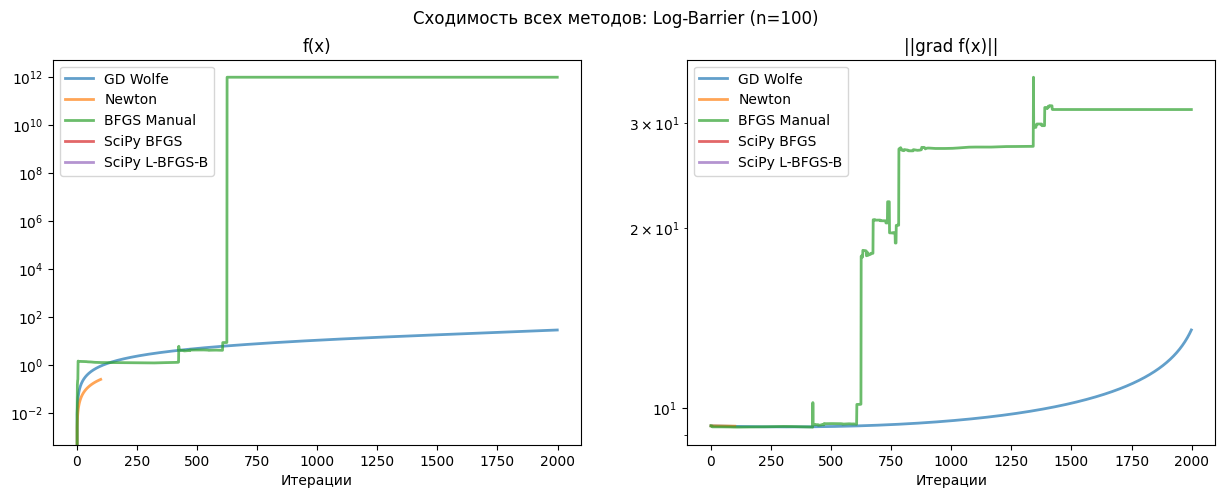


>>> Тест: Himmelblau (n=2)
Метод                | Итер   | Время (с) 
---------------------------------------------
GD Wolfe             | 20     | 0.0057
Newton               | 24     | 0.0034
BFGS Manual          | 6      | 0.0018
SciPy BFGS           | 11     | 0.0045
SciPy L-BFGS-B       | 8      | 0.0027


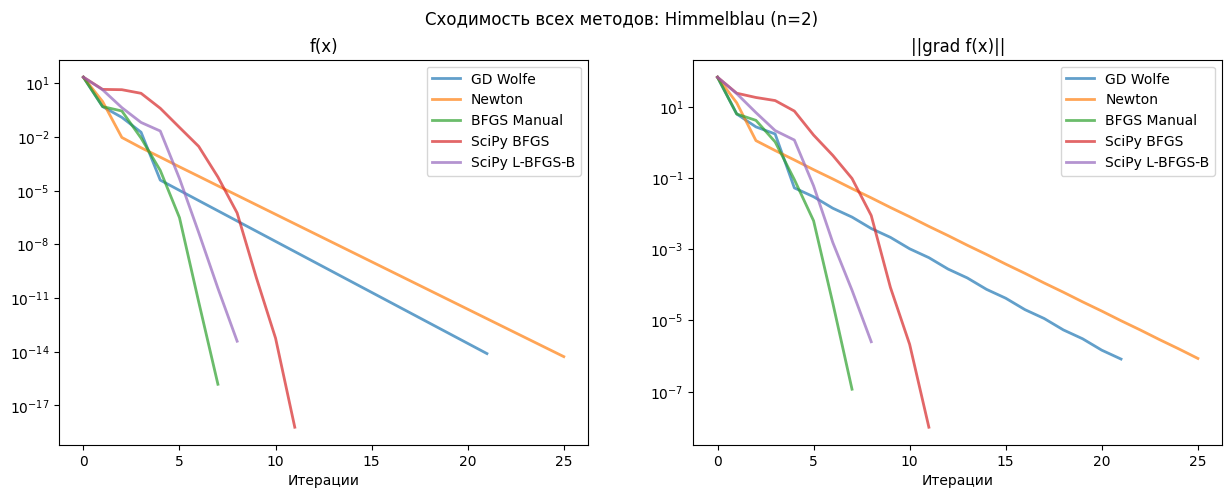

In [20]:
import numpy as np
import time
from scipy.optimize import line_search, minimize
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# --- 1. Определение функций ---
N_100 = 100
np.random.seed(42)
A_MAT = np.random.randn(N_100, N_100) * 0.1

def f_log_barrier(x, A=A_MAT):
    terms_a = 1 - A @ x
    terms_x = 1 - x**2
    if np.any(terms_a <= 1e-9) or np.any(terms_x <= 1e-9):
        return 1e12
    return -np.sum(np.log(terms_a)) - np.sum(np.log(terms_x))

def grad_log_barrier(x, A=A_MAT):
    terms_a = 1 - A @ x
    g_a = -A.T @ (1.0 / (terms_a + 1e-12))
    g_x = 2 * x / (1 - x**2 + 1e-12)
    return g_a + g_x

def hess_log_barrier(x, A=A_MAT):
    terms_a = 1 - A @ x
    w = 1.0 / (terms_a**2 + 1e-12)
    H = (A.T * w) @ A
    diag_x = (2 * (1 + x**2)) / ((1 - x**2)**2 + 1e-12)
    return H + np.diag(diag_x)

def f_himmelblau(x):
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

def grad_himmelblau(x):
    x1, x2 = x[0], x[1]
    return np.array([4*x1*(x1**2+x2-11) + 2*(x1+x2**2-7), 2*(x1**2+x2-11) + 4*x2*(x1+x2**2-7)])

def hess_himmelblau(x):
    x1, x2 = x[0], x[1]
    return np.array([[12*x1**2+4*x2-42, 4*x1*x2+2], [4*x1*x2+2, 4*x1+12*x2**2-42]])

# --- 2. Оптимизаторы ---

class Optimizer:
    def __init__(self, f, grad, hess=None, name=""):
        self.f, self.grad, self.hess, self.name = f, grad, hess, name
        self.history_f = []
        self.history_gn = []
        self.iters, self.time = 0, 0

    def log_state(self, x):
        self.history_f.append(self.f(x))
        self.history_gn.append(np.linalg.norm(self.grad(x)))

    def get_step_wolfe(self, x, d):
        try:
            res = line_search(self.f, self.grad, x, d)
            return res[0] if res[0] is not None else 1e-4
        except:
            return 1e-4

class GD_Wolfe(Optimizer):
    def run(self, x0, max_iter=2000, tol=1e-6):
        x = x0.copy()
        start = time.time()
        for i in range(max_iter):
            self.log_state(x)
            if self.history_gn[-1] < tol: break
            d = -self.grad(x)
            alpha = self.get_step_wolfe(x, d)
            x = x + alpha * d
            self.iters = i
        self.time = time.time() - start
        return x

class Newton(Optimizer):
    def run(self, x0, max_iter=100, tol=1e-6):
        x = x0.copy()
        start = time.time()
        for i in range(max_iter):
            self.log_state(x)
            if self.history_gn[-1] < tol: break
            g, H = self.grad(x), self.hess(x)
            try:
                d = np.linalg.solve(H, -g)
            except: d = -g
            alpha = self.get_step_wolfe(x, d)
            x = x + alpha * d
            self.iters = i
        self.time = time.time() - start
        return x

class BFGS_Manual(Optimizer):
    def run(self, x0, max_iter=2000, tol=1e-6):
        x = x0.copy()
        n = len(x)
        H_inv = np.eye(n)
        start = time.time()
        for i in range(max_iter):
            self.log_state(x)
            g = self.grad(x)
            if np.linalg.norm(g) < tol: break
            d = -H_inv @ g
            alpha = self.get_step_wolfe(x, d)
            s = alpha * d
            x_next = x + s
            y = self.grad(x_next) - g
            rho = 1.0 / (y.T @ s + 1e-10)
            I = np.eye(n)
            H_inv = (I - rho * np.outer(s, y)) @ H_inv @ (I - rho * np.outer(y, s)) + rho * np.outer(s, s)
            x = x_next
            self.iters = i
        self.time = time.time() - start
        return x

# --- 3. Эксперимент ---

def run_experiment(f_dict, x0, title):
    print(f"\n>>> Тест: {title}")
    results = []

    # 1-3. Ручные методы
    methods = [
        GD_Wolfe(f_dict['f'], f_dict['grad'], name="GD Wolfe"),
        Newton(f_dict['f'], f_dict['grad'], f_dict['hess'], name="Newton"),
        BFGS_Manual(f_dict['f'], f_dict['grad'], name="BFGS Manual")
    ]
    for m in methods:
        m.run(x0)
        results.append(m)

    # 4-5. SciPy методы
    for s_name in ['BFGS', 'L-BFGS-B']:
        m_sci = Optimizer(f_dict['f'], f_dict['grad'], name=f"SciPy {s_name}")

        # Добавляем начальную точку вручную
        m_sci.log_state(x0)

        def sci_callback(xk):
            # SciPy иногда передает объект OptimizeResult, иногда просто x
            current_x = xk.x if hasattr(xk, 'x') else xk
            m_sci.log_state(current_x)

        t0 = time.time()
        res = minimize(f_dict['f'], x0, method=s_name, jac=f_dict['grad'],
                       callback=sci_callback, options={'gtol': 1e-6})
        m_sci.time = time.time() - t0
        m_sci.iters = res.nit
        results.append(m_sci)

    # Таблица
    print(f"{'Метод':<20} | {'Итер':<6} | {'Время (с)':<10}")
    print("-" * 45)
    for r in results:
        print(f"{r.name:<20} | {r.iters:<6} | {r.time:.4f}")

    # Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Сходимость всех методов: {title}')

    for r in results:
        ax1.plot(r.history_f, label=r.name, lw=2, alpha=0.7)
        ax2.plot(r.history_gn, label=r.name, lw=2, alpha=0.7)

    ax1.set_title('f(x)')
    ax1.set_yscale('log')
    ax1.set_xlabel('Итерации')
    ax1.legend()

    ax2.set_title('||grad f(x)||')
    ax2.set_yscale('log')
    ax2.set_xlabel('Итерации')
    ax2.legend()
    plt.show()

# Запуск
run_experiment({'f': f_log_barrier, 'grad': grad_log_barrier, 'hess': hess_log_barrier},
               np.zeros(N_100), "Log-Barrier (n=100)")

run_experiment({'f': f_himmelblau, 'grad': grad_himmelblau, 'hess': hess_himmelblau},
               np.array([3.5, 2.5]), "Himmelblau (n=2)")